# PHẦN 3: PHÂN TÍCH THỰC NGHIỆM VÀ ĐÁNH GIÁ THUẬT TOÁN

**Nhóm thực hiện:** Nhóm 13

**Nội dung:** Đánh giá hiệu năng và độ ổn định số học của 3 phương pháp giải hệ phương trình tuyến tính $Ax=b$ (khử Gauss, phân rã SVD, Gauss-Seidel) trên các cấu trúc ma trận khác nhau.

### 1. Môi trường thực nghiệm
Để đảm bảo tính khách quan khi so sánh thời gian thực thi, toàn bộ các phép đo được tiến hành trên môi trường phần cứng và phần mềm sau:

| Thành phần | Thông tin |
|:-----------|:----------|
| **CPU** | Intel Core i7-10610U |
| **RAM** | 16GB |
| **OS** | Windows 11 Pro |
| **Môi trường** | Python 3.11, Jupyter Notebook, Thư viện: NumPy, Pandas |

---

In [321]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150  # Độ phân giải

# Tải dữ liệu
df = pd.read_json('benchmark_results.json')

# Xử lý các giá trị không hội tụ/lỗi (null -> inf)
df['avg_error'] = df['avg_error'].fillna(np.inf)

print(f"Đã tải thành công {len(df)} bản ghi thực nghiệm.")

Đã tải thành công 45 bản ghi thực nghiệm.


### 3.2. Bảng số liệu thống kê

Dưới đây là các bảng số liệu chi tiết về thời gian thực thi trung bình, sai số tương đối và thuật toán tối ưu nhất cho từng kích thước $n$. Để đánh giá toàn diện cả về hiệu năng lẫn độ ổn định, thực nghiệm được tiến hành trên 3 loại ma trận đặc trưng:

* **Ma trận Chéo trội (Diagonally Dominant):** Là ma trận có trị tuyệt đối phần tử trên đường chéo chính lớn hơn tổng trị tuyệt đối các phần tử còn lại trên cùng hàng. Loại ma trận này đảm bảo điều kiện hội tụ tuyệt đối và nhanh chóng cho các phương pháp lặp như Gauss-Seidel.
* **Ma trận Đối xứng Xác định dương (SPD - Symmetric Positive Definite):** Là loại ma trận có tính chất "đẹp" và ổn định, thường xuất hiện phổ biến trong các bài toán tối ưu hóa và mô phỏng hệ thống vật lý thực tế.
* **Ma trận Hilbert:** Nổi tiếng là ma trận mất ổn định số học, số điều kiện của ma trận Hilbert tăng theo hàm mũ khi $n$ tăng. Đây là loại ma trận dùng để đánh giá sự suy giảm độ chính xác sai số của các thuật toán khi giải hệ phương trình.

In [322]:
# Tạo bảng pivot với 2 giá trị ban đầu
pivot_combined = df.pivot(index=['matrix_type', 'n'], columns='method', values=['avg_time', 'avg_error'])
pivot_combined = pivot_combined.swaplevel(axis=1).sort_index(axis=1)

# Đặt tên các cột giá trị
pivot_combined = pivot_combined.rename(columns={'avg_time': 'Thời gian (s)', 'avg_error': 'Sai số tương đối'})


pivot_combined = pivot_combined.reset_index()

# Tạo lại cấu trúc header mới
new_columns = []
for col in pivot_combined.columns:
    if col[0] == 'matrix_type':
        new_columns.append(('', 'Loại ma trận'))
    elif col[0] == 'n':
        new_columns.append(('', 'Kích thước (n)'))
    else:
        new_columns.append(col)

# Ép hệ thống cột mới vào bảng
pivot_combined.columns = pd.MultiIndex.from_tuples(new_columns)

# Format hiển thị số liệu
format_dict = {}
for method in [m for m in pivot_combined.columns.levels[0] if m != '']:
    format_dict[(method, 'Thời gian (s)')] = "{:.4f}"
    format_dict[(method, 'Sai số tương đối')] = lambda x: "inf" if x == np.inf or pd.isna(x) else "{:.2e}".format(x)

# Format bảng
styled_combined = pivot_combined.style.set_caption("Bảng 1: Tổng hợp thời gian thực thi và sai số tương đối chi tiết") \
    .format(format_dict) \
    .hide(axis="index") \
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#27ae60'), ('margin-bottom', '10px')]
    }, {
        'selector': 'th',
        'props': [('text-align', 'center'), ('vertical-align', 'middle')]
    }, {
        'selector': 'td',
        'props': [('text-align', 'center')]
    }])

display(styled_combined)

In [323]:
# Chỉ xét những lần chạy thành công
df_success = df[df['avg_error'] != np.inf]

# Tìm index của phương pháp có thời gian nhỏ nhất cho mỗi loại ma trận và kích thước
idx_fastest = df_success.groupby(['matrix_type', 'n'])['avg_time'].idxmin()

# Trích xuất dữ liệu
df_fastest = df.loc[idx_fastest, ['matrix_type', 'n', 'method', 'avg_time']]
df_fastest.columns = ['Loại ma trận', 'Kích thước (n)', 'Phương pháp nhanh nhất', 'Thời gian (giây)']

# Format
styled_fastest = df_fastest.style.set_caption("Bảng 2: Phương pháp thực thi nhanh nhất theo từng kích thước") \
    .format({'Thời gian (giây)': "{:.4f}"}) \
    .hide(axis="index") \
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#27ae60'), ('margin-bottom', '10px')]
    }])

display(styled_fastest)

Loại ma trận,Kích thước (n),Phương pháp nhanh nhất,Thời gian (giây)
diagonally_dominant,50,Gauss-Seidel,0.0025
diagonally_dominant,100,Gauss-Seidel,0.0128
diagonally_dominant,200,Gauss-Seidel,0.0355
diagonally_dominant,500,Gauss-Seidel,0.1962
diagonally_dominant,1000,Gauss-Seidel,0.7220
hilbert,50,Phân rã SVD,0.0207
hilbert,100,Phân rã SVD,0.1477
hilbert,200,Phân rã SVD,1.0618
hilbert,500,Khử Gauss,10.1839
hilbert,1000,Khử Gauss,67.8126


### 3.3. Trực quan hóa phân tích hiệu năng và độ ổn định
Phương pháp khử Gauss và phân rã SVD đều có độ phức tạp thời gian là $\mathcal{O}(n^3)$. Để kiểm chứng, nhóm vẽ đồ thị log-log và biểu đồ cột hiển thị thời gian chạy và sai số tương đối theo kích thước $n$ trên cả 3 loại ma trận.

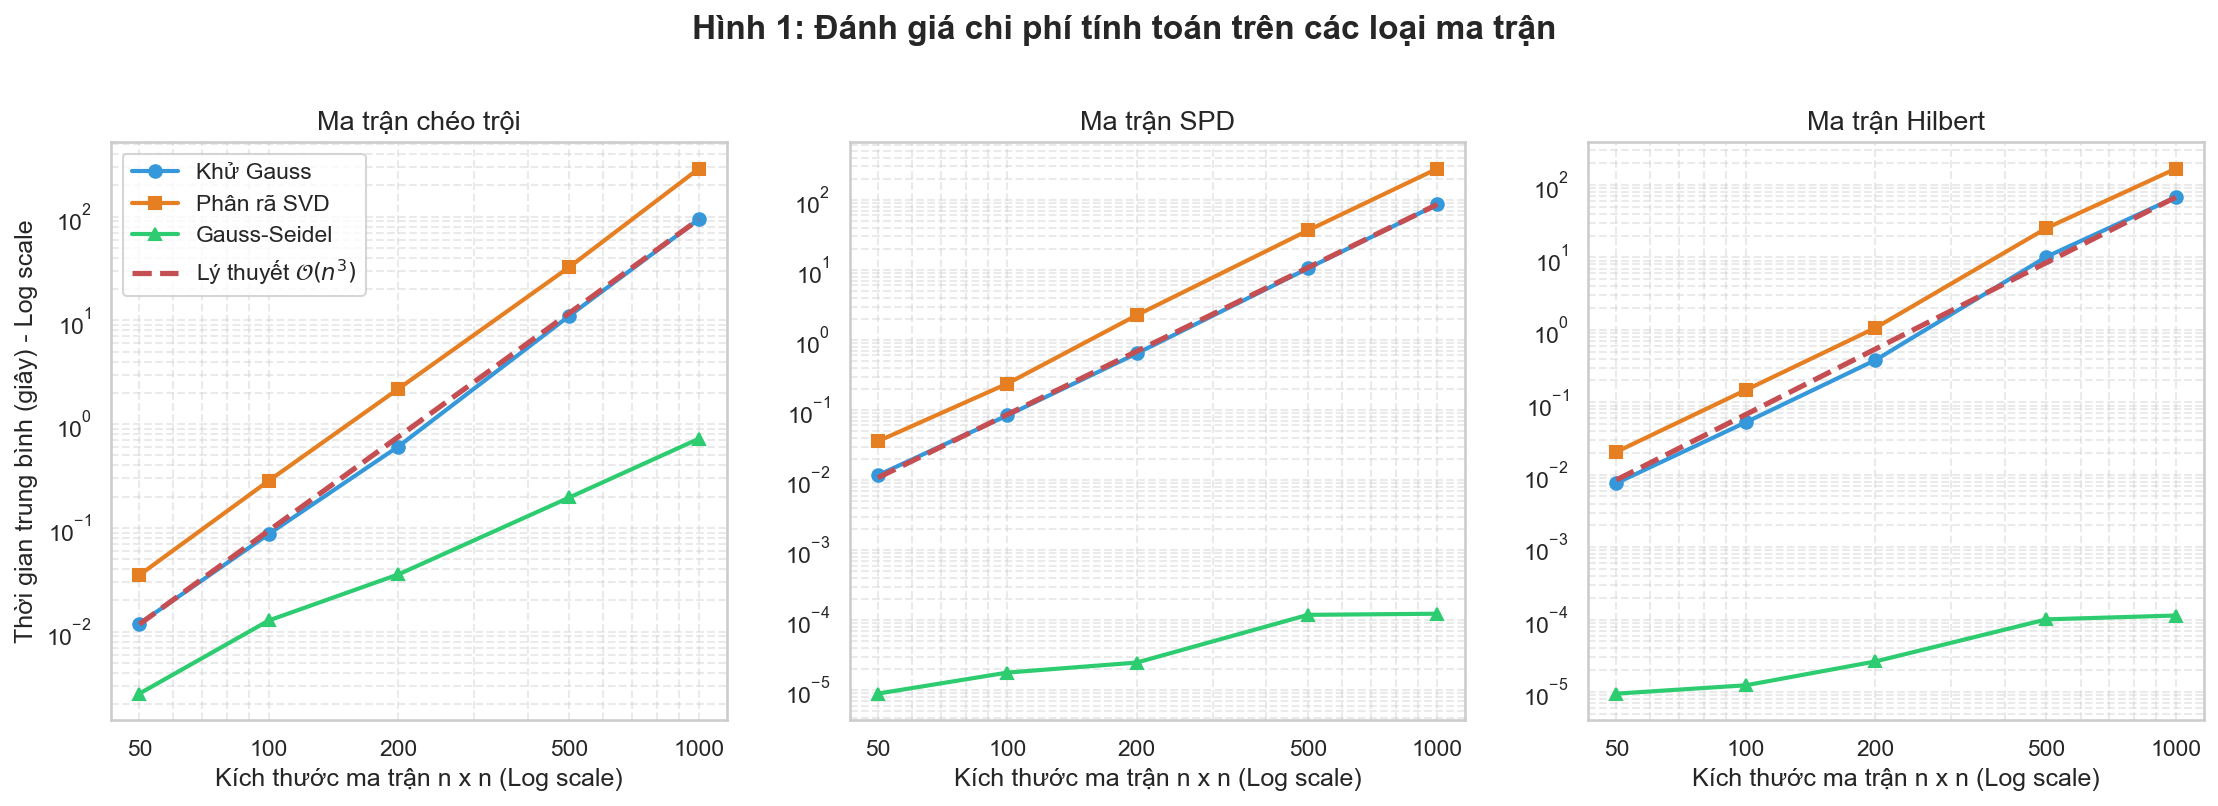

In [324]:
# Lấy danh sách 3 loại ma trận
matrix_types = ['diagonally_dominant', 'spd', 'hilbert']
titles = ['Ma trận chéo trội', 'Ma trận SPD', 'Ma trận Hilbert']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Hình 1: Đánh giá chi phí tính toán trên các loại ma trận', fontsize=16, fontweight='bold', y=1.05)

# Vẽ 3 biểu đồ
for i, m_type in enumerate(matrix_types):
    ax = axes[i]
    df_subset = df[df['matrix_type'] == m_type]
    
    # Vẽ đường đi
    for method, marker, color in zip(['Khử Gauss', 'Phân rã SVD', 'Gauss-Seidel'], ['o', 's', '^'], ['#3498db', '#e67e22', '#2ecc71']):
        data = df_subset[df_subset['method'] == method]
        ax.plot(data['n'], data['avg_time'], marker=marker, linewidth=2, color=color, label=f'{method}')
    
    # Vẽ đường lý thuyết O(n^3)
    n_ref = 1000
    gauss_time = df_subset[df_subset['n'] == n_ref]['avg_time'].values[0]
    c_constant = gauss_time / (n_ref ** 3)
    n_theory = np.array([50, 100, 200, 500, 1000])
    ax.plot(n_theory, c_constant * (n_theory ** 3), 'r--', linewidth=2.5, label=r'Lý thuyết $\mathcal{O}(n^3)$')

    ax.set_title(titles[i], fontsize=13)
    ax.set_xlabel('Kích thước ma trận n x n (Log scale)')
    if i == 0:
        ax.set_ylabel('Thời gian trung bình (giây) - Log scale')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks([50, 100, 200, 500, 1000])
    ax.set_xticklabels(['50', '100', '200', '500', '1000'])
    ax.grid(True, which="both", ls="--", alpha=0.4)
    if i == 0:
        ax.legend()

plt.show()

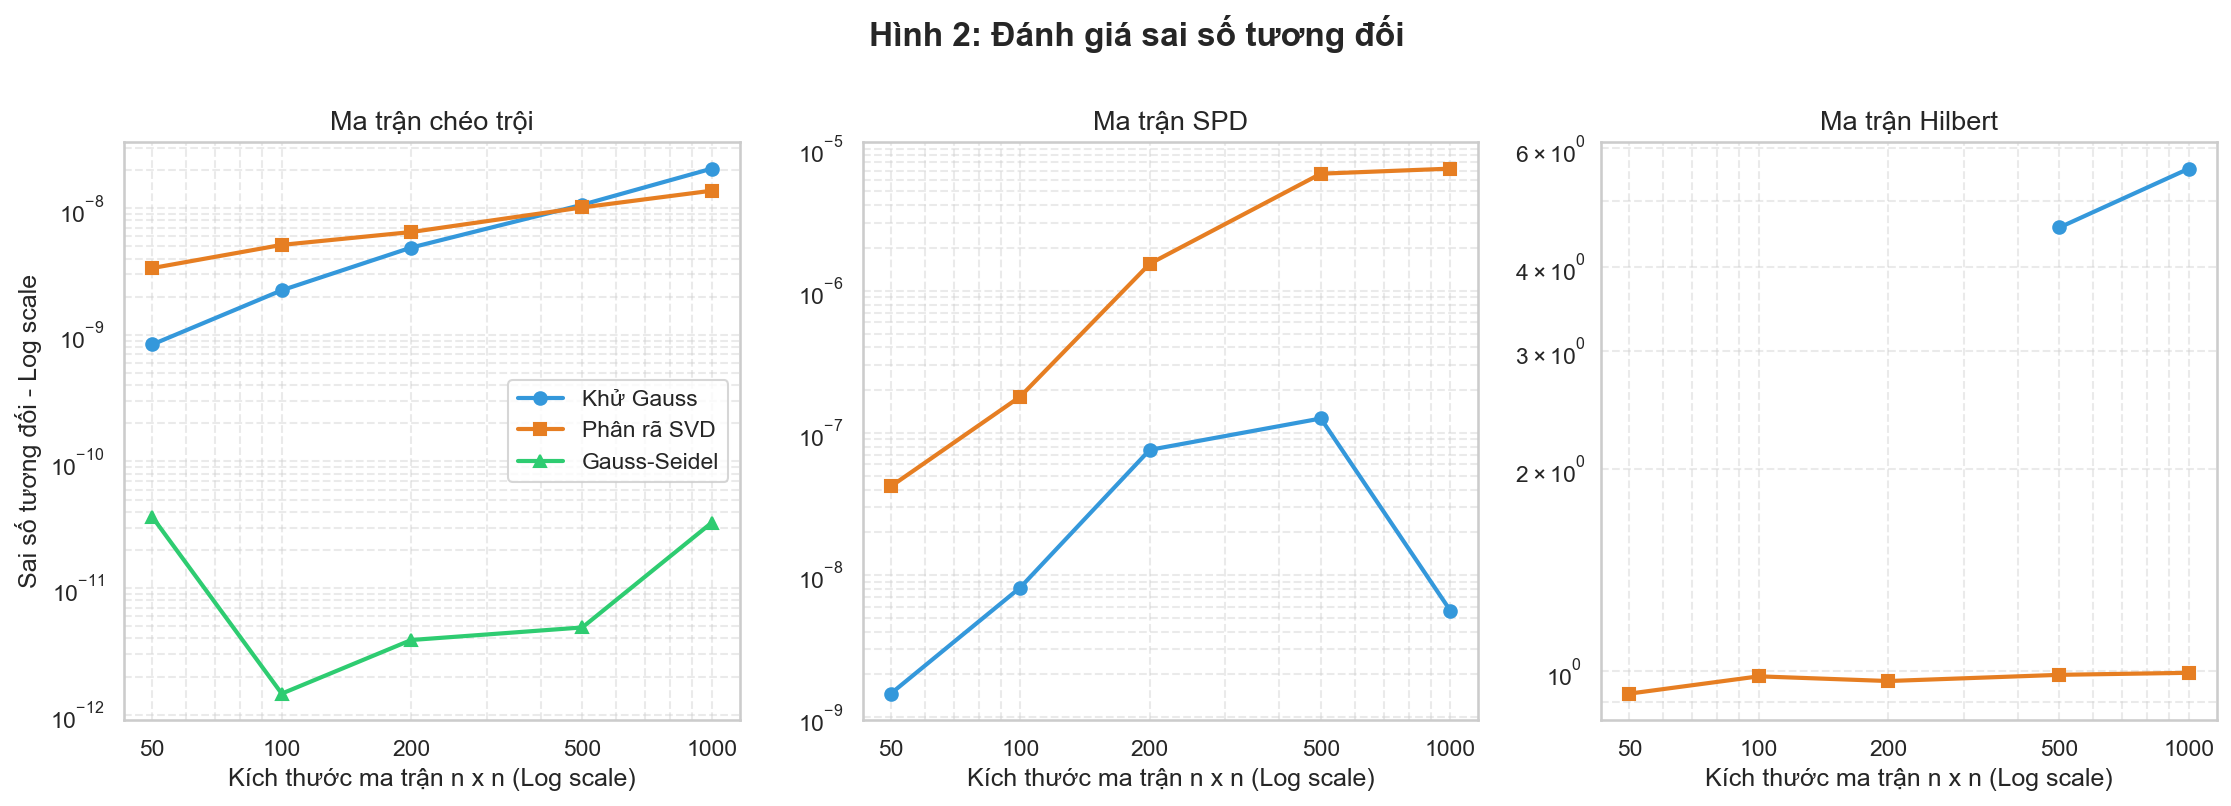

In [325]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Hình 2: Đánh giá sai số tương đối', fontsize=16, fontweight='bold', y=1.05)

# Vẽ 3 biểu đồ
for i, m_type in enumerate(matrix_types):
    ax = axes[i]
    df_subset = df[df['matrix_type'] == m_type]
    
    # Vẽ đường đi
    for method, marker, color in zip(['Khử Gauss', 'Phân rã SVD', 'Gauss-Seidel'], ['o', 's', '^'], ['#3498db', '#e67e22', '#2ecc71']):
        data = df_subset[df_subset['method'] == method]

        # Lọc bỏ giá trị inf để không làm hỏng trục đồ thị
        data_valid = data[data['avg_error'] != np.inf]
        if not data_valid.empty:
            ax.plot(data_valid['n'], data_valid['avg_error'], marker=marker, linewidth=2, color=color, label=f'{method}')
            
    ax.set_title(titles[i], fontsize=13)
    ax.set_xlabel('Kích thước ma trận n x n (Log scale)')
    if i == 0:
        ax.set_ylabel('Sai số tương đối - Log scale')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks([50, 100, 200, 500, 1000])
    ax.set_xticklabels(['50', '100', '200', '500', '1000'])
    ax.grid(True, which="both", ls="--", alpha=0.4)
    if i == 0:
        ax.legend()

plt.show()

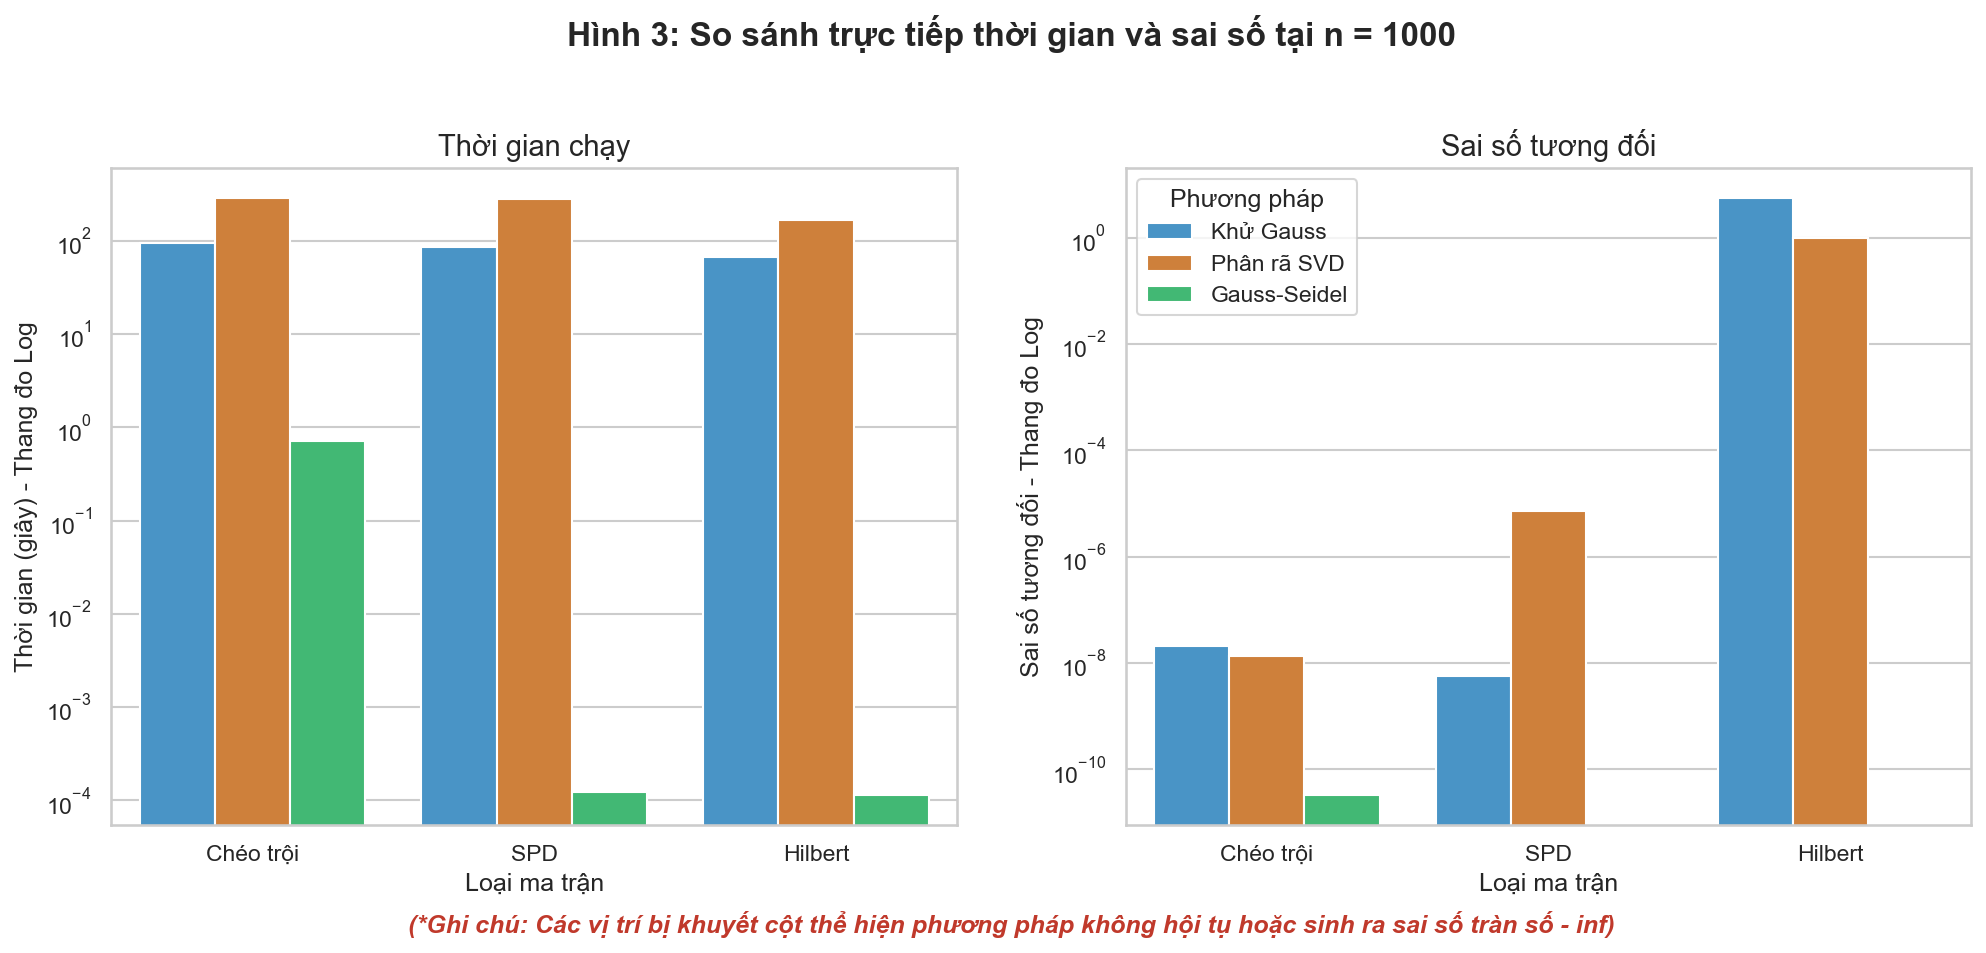

In [326]:
# Lọc mốc n = 1000
df_1000 = df[df['n'] == 1000].copy()

# Đổi inf thành NaN để vẽ cột sai số không bị lỗi
df_1000['avg_error_plot'] = df_1000['avg_error'].replace(np.inf, np.nan)

# Tạo 1 khung ảnh chứa 2 biểu đồ cột
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hình 3: So sánh trực tiếp thời gian và sai số tại n = 1000', fontsize=16, fontweight='bold', y=1.05)

# Biểu đồ cột thời gian chạy
sns.barplot(x='matrix_type', y='avg_time', hue='method', data=df_1000, 
            palette=['#3498db', '#e67e22', '#2ecc71'], ax=axes[0])
axes[0].set_title('Thời gian chạy', fontsize=14)
axes[0].set_xlabel('Loại ma trận', fontsize=12)
axes[0].set_ylabel('Thời gian (giây) - Thang đo Log', fontsize=12)
axes[0].set_xticks(ticks=[0, 1, 2], labels=['Chéo trội', 'SPD', 'Hilbert'])
axes[0].set_yscale('log')

# Biểu đồ cột sai số tương đối
ax_error = sns.barplot(x='matrix_type', y='avg_error_plot', hue='method', data=df_1000, 
                       palette=['#3498db', '#e67e22', '#2ecc71'], ax=axes[1])
axes[1].set_title('Sai số tương đối', fontsize=14)
axes[1].set_xlabel('Loại ma trận', fontsize=12)
axes[1].set_ylabel('Sai số tương đối - Thang đo Log', fontsize=12)
axes[1].set_xticks(ticks=[0, 1, 2], labels=['Chéo trội', 'SPD', 'Hilbert'])
axes[1].set_yscale('log')
axes[1].legend(title='Phương pháp')

# Tắt bảng chú thích biểu đồ bên trái
axes[0].get_legend().remove()

# Thêm dòng chú thích
plt.subplots_adjust(bottom=0.15) 
note_text = "(*Ghi chú: Các vị trí bị khuyết cột thể hiện phương pháp không hội tụ hoặc sinh ra sai số tràn số - inf)"
fig.text(0.5, 0.03, note_text, ha='center', fontsize=12, fontweight='bold', color='#c0392b', style='italic')

plt.show()

### 3.4. Nhận xét và Kết luận chung

Dựa trên bảng số liệu và các biểu đồ trực quan, nhóm rút ra các đánh giá chi tiết về hiệu năng và độ ổn định như sau:

**1. Đánh giá chi phí tính toán (Thời gian)**
- **Khử Gauss và phân rã SVD (trên ma trận Chéo trội):** Đồ thị thời gian của hai phương pháp này đều bám sát đường độ phức tạp lý thuyết $\mathcal{O}(n^3)$. Tại kích thước $n=1000$, khử Gauss thực thi mất **94.05 giây**. Trong khi đó, SVD tốn nhiều thời gian hơn đáng kể (**289.47 giây**) do hệ thống tốn thêm chi phí để phân rã các ma trận trực giao.
- **Gauss-Seidel (trên ma trận Chéo trội):** Thể hiện tốc độ thực thi rất nhanh. Tại $n=1000$, phương pháp lặp này chỉ tiêu tốn **0.72 giây**, chứng minh hiệu năng vượt trội khi ma trận đầu vào thỏa mãn điều kiện hội tụ.
- **Gauss-Seidel (trên ma trận SPD và Hilbert):** Thuật toán chủ động ngắt sớm (thời gian ghi nhận $\approx$ **0.0001 giây**). Nguyên nhân là do chương trình nhận diện ma trận không đạt chuẩn chéo trội nên dừng thực thi và trả về sai số `inf` để tránh rơi vào vòng lặp vô hạn.

**2. Đánh giá độ ổn định số học (Sai số)**
- Trên ma trận **Chéo trội**, các phương pháp đều duy trì độ chính xác rất cao, sai số tương đối dao động từ **$10^{-12}$ đến $10^{-7}$**. 
- Trên ma trận **SPD**, phương pháp khử Gauss và SVD cũng duy trì sự ổn định với sai số cực nhỏ (từ **$10^{-9}$ đến $10^{-5}$**).
- Trên ma trận **Hilbert**, tính mất ổn định số học làm suy giảm nghiêm trọng độ chính xác. **Khử Gauss** trả về sai số rất lớn (lên tới **5.59** tại $n=1000$) hoặc tràn số ở các mốc $n$ nhỏ, trong khi đó **SVD** giữ được độ ổn định tốt hơn (khoảng **0.99** tại $n=1000$). Mặt khác, SVD không bị tràn số cho thấy khả năng chống chịu lỗi tốt hơn trước dữ liệu mất ổn định. **Gauss-Seidel** luôn bị tràn số với mọi trường hợp kiểm thử.

**3. Kết luận chung**
- Việc lựa chọn thuật toán cần dựa trên sự cân bằng giữa **tốc độ** và **độ ổn định**.
- Nếu ưu tiên **tốc độ** trên các ma trận có tính chéo trội, **Gauss-Seidel** là lựa chọn tối ưu nhất.
- Đối với các hệ phương trình tổng quát có cấu trúc tốt (như SPD), **Khử Gauss** mang lại sự cân bằng hoàn hảo giữa thời gian giải và độ chính xác của nghiệm.
- Nếu hệ phương trình kém điều kiện (như Hilbert), **SVD** là phương án an toàn nhất để tránh các lỗi tràn số nghiêm trọng, bất chấp việc tốn nhiều chi phí thời gian hơn.